In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
data = pd.read_csv('hdb_resale_prices_with_travel_times.csv')
data = data[data['valid_in_town_area'] == 1]

In [16]:
numeric_data = data.apply(pd.to_numeric, errors='coerce')

print("Usable numeric values per column:")
print(numeric_data.count())

print("Columns with at least 2 numeric values:")
print(numeric_data.columns[numeric_data.count() >= 2])

Usable numeric values per column:
dataset_id                            0
dataset_name                          0
_id                              204974
month                                 0
town                                  0
flat_type                             0
block                            130077
street_name                           0
storey_range                          0
floor_area_sqm                   204974
flat_model                            0
lease_commence_date              204974
remaining_lease                       0
resale_price                     204974
LATITUDE                         204974
LONGITUDE                        204974
remaining_lease_numeric          204974
valid_in_town_area               204974
nearest_mrt_exit                      0
distance_to_mrt                  204974
nearest_hawker                        0
distance_to_hawker               204974
nearest_activesg                      0
distance_to_activesg             204974
neares

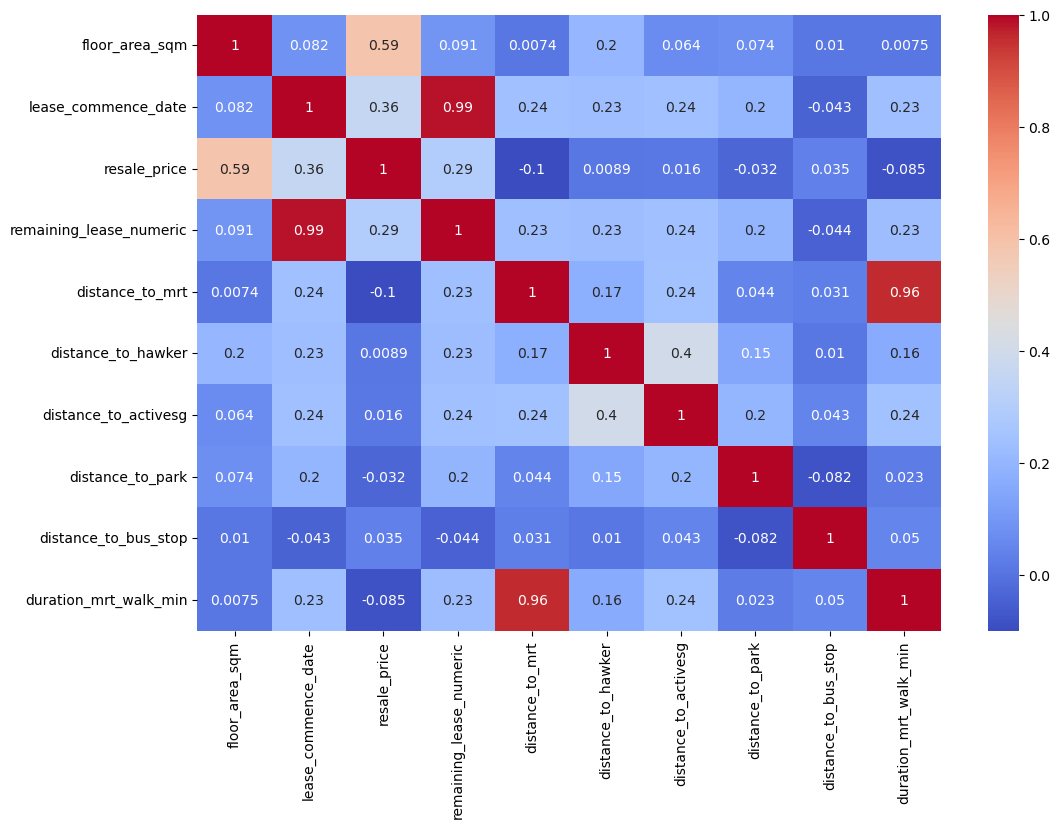

In [21]:
corr_cols = [
    'floor_area_sqm',
    'lease_commence_date',
    'resale_price',
    'remaining_lease_numeric',
    'distance_to_mrt',
    'distance_to_hawker',
    'distance_to_activesg',
    'distance_to_park',
    'distance_to_bus_stop',
    'duration_mrt_walk_min'
]

corr = data[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

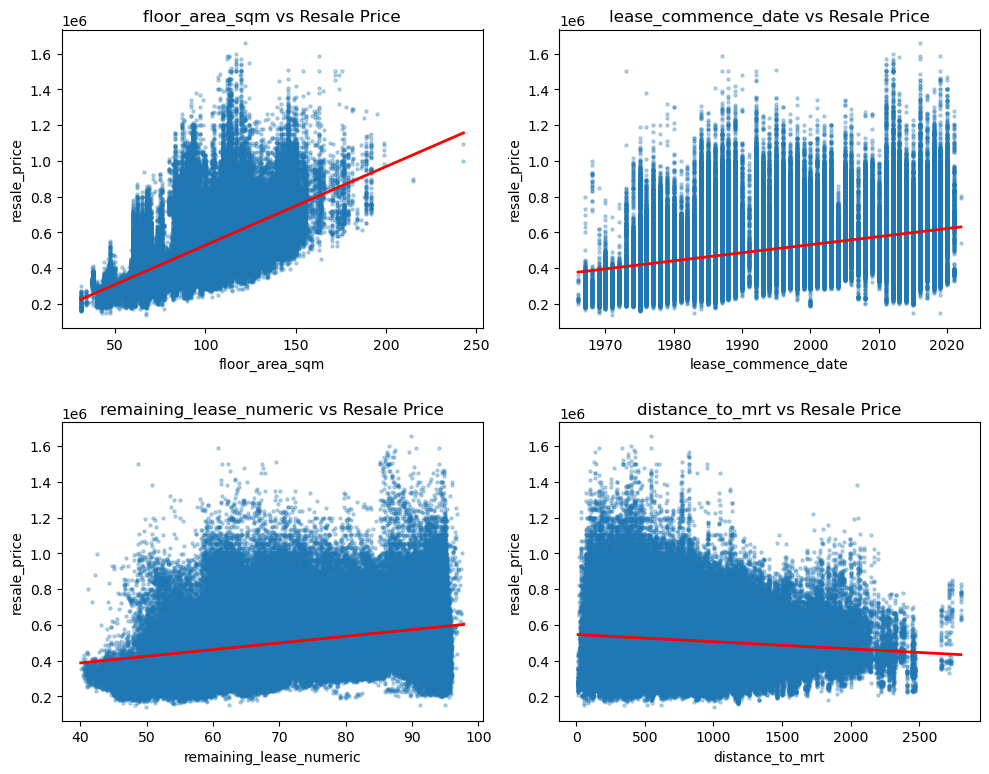

In [29]:
high_corr = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_numeric', 'distance_to_mrt']
# plot scatter plots for these columns against resale_price in the same subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, col in enumerate(high_corr):
    sns.regplot(
        data=data,
        x=col,
        y='resale_price',
        scatter_kws={'s': 5, 'alpha': 0.3},
        line_kws={'linewidth': 2, 'color': 'red'},
        ax=axes[i//2, i%2]
    )
    axes[i//2, i%2].set_title(f'{col} vs Resale Price')

plt.tight_layout()
plt.show()